In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve
)

In [19]:
#Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

In [20]:
df = pd.read_csv('../data/heart.csv')

print(f'Dataset shape: {df.shape[0]} Row × {df.shape[1]} Column')

df.head()

Dataset shape: 1025 Row × 14 Column


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [21]:
#
print('Data information:')
df.info()
print('\n Descriptive statistics:')
df.describe().round(2)

Data information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB

 Descriptive statistics:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00
mean,54.43,0.70,0.94,131.61,246.00,0.15,0.53,149.11,0.34,1.07,1.39,0.75,2.32,0.51
std,9.07,0.46,1.03,17.52,51.59,0.36,0.53,23.01,0.47,1.18,0.62,1.03,0.62,0.50
min,29.00,0.00,0.00,94.00,126.00,0.00,0.00,71.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,48.00,0.00,0.00,120.00,211.00,0.00,0.00,132.00,0.00,0.00,1.00,0.00,2.00,0.00
50%,56.00,1.00,1.00,130.00,240.00,0.00,1.00,152.00,0.00,0.80,1.00,0.00,2.00,1.00
75%,61.00,1.00,2.00,140.00,275.00,0.00,1.00,166.00,1.00,1.80,2.00,1.00,3.00,1.00
max,77.00,1.00,3.00,200.00,564.00,1.00,2.00,202.00,1.00,6.20,2.00,4.00,3.00,1.00


In [22]:
missing = df.isnull().sum()
print('Is Null:')
print(missing)

Is Null:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [23]:
duplicates = df.duplicated().sum()
print('Is Duplicated:')
print(duplicates)

if duplicates > 0:
    df = df.drop_duplicates()
    print(f'After drop_duplicates: {df.shape}')

Is Duplicated:
723
After drop_duplicates: (302, 14)


In [25]:
# Outlier detection using IQR method
numerical_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outlier_count = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
    print(f'  {col}: {outlier_count} outlier(s) (allowed range: {lower_bound:.1f} - {upper_bound:.1f})')

  age: 0 outlier(s) (allowed range: 28.5 - 80.5)
  trestbps: 9 outlier(s) (allowed range: 90.0 - 170.0)
  chol: 5 outlier(s) (allowed range: 115.4 - 370.4)
  thalach: 1 outlier(s) (allowed range: 84.1 - 215.1)
  oldpeak: 5 outlier(s) (allowed range: -2.4 - 4.0)


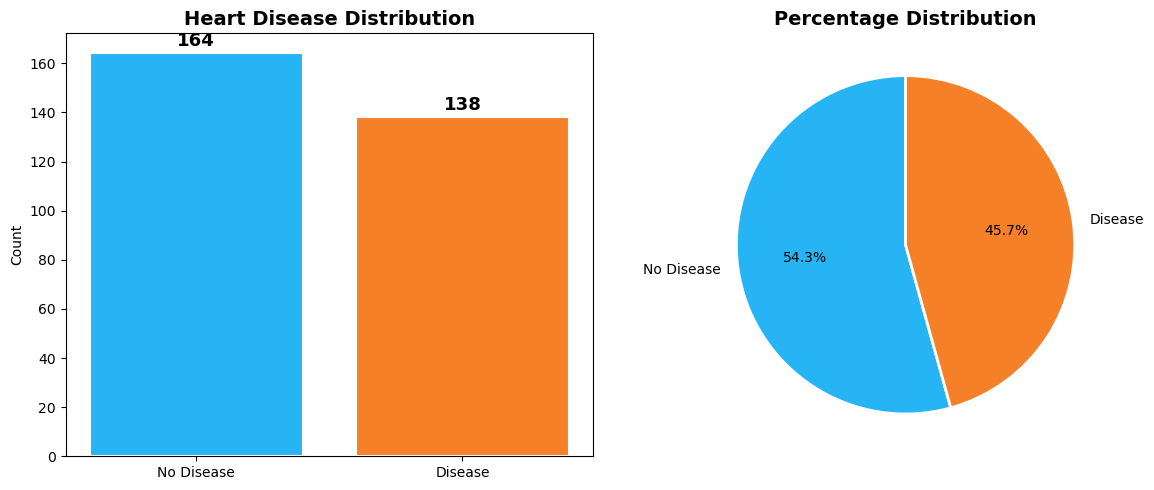


 Ratio: 54.3% Disease | 45.7% No Disease


In [30]:
# Distribution of target variable
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

target_counts = df['target'].value_counts()
labels = ['No Disease', 'Disease']

# Bar chart
axes[0].bar(labels, target_counts.values, color=['#27B4F5', '#F58027'], edgecolor='white', linewidth=1.5)
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 3, str(v), ha='center', fontweight='bold', fontsize=13)
axes[0].set_title('Heart Disease Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')

# Pie chart
axes[1].pie(target_counts.values, labels=labels, autopct='%1.1f%%',
            colors=['#27B4F5', '#F58027'], startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Percentage Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()
print(f'\n Ratio: {target_counts[1]/len(df)*100:.1f}% Disease | {target_counts[0]/len(df)*100:.1f}% No Disease')

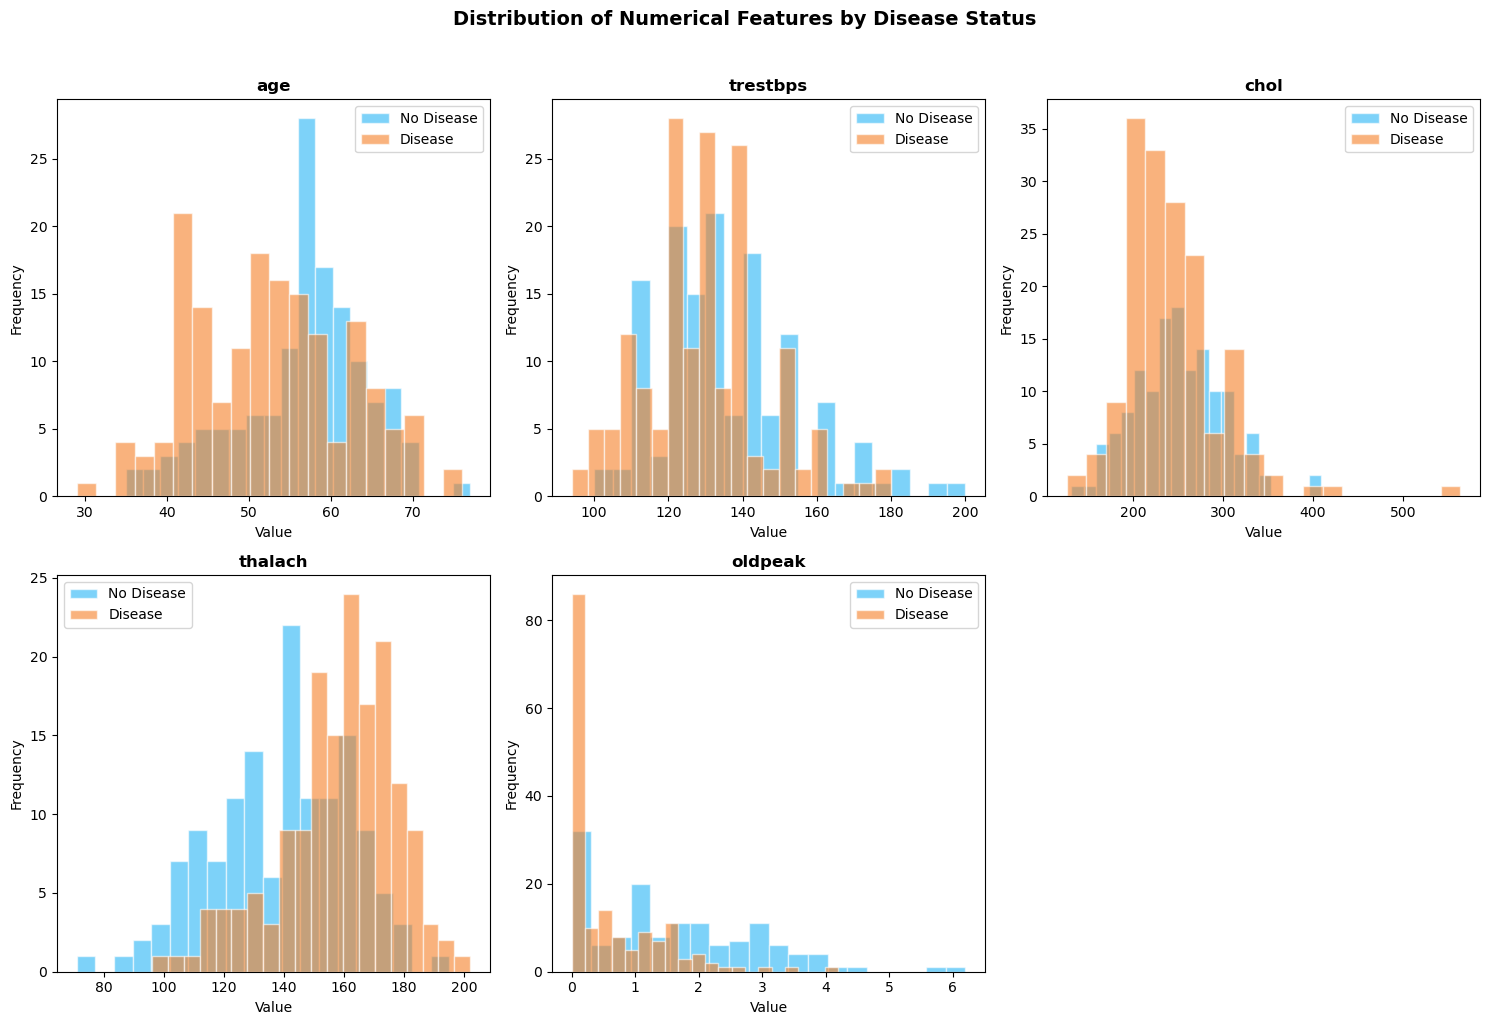

In [39]:
# Distribution of numerical features
fig, axes = plt.subplots( 2,3, figsize=(15, 10))
axes = axes.flatten()

for idx, col in enumerate(numerical_cols):
    for val, color, label in [(0, '#27B4F5', 'No Disease'), (1, '#F58027', 'Disease')]:
        axes[idx].hist(df[df['target']==val][col], alpha=0.6,
                       color=color, label=label, bins=20, edgecolor='white')
    axes[idx].set_title(col, fontsize=12, fontweight='bold')
    axes[idx].legend()
    axes[idx].set_xlabel('Value')
    axes[idx].set_ylabel('Frequency')

axes[-1].axis('off')  # Hide the extra subplot
plt.suptitle('Distribution of Numerical Features by Disease Status', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

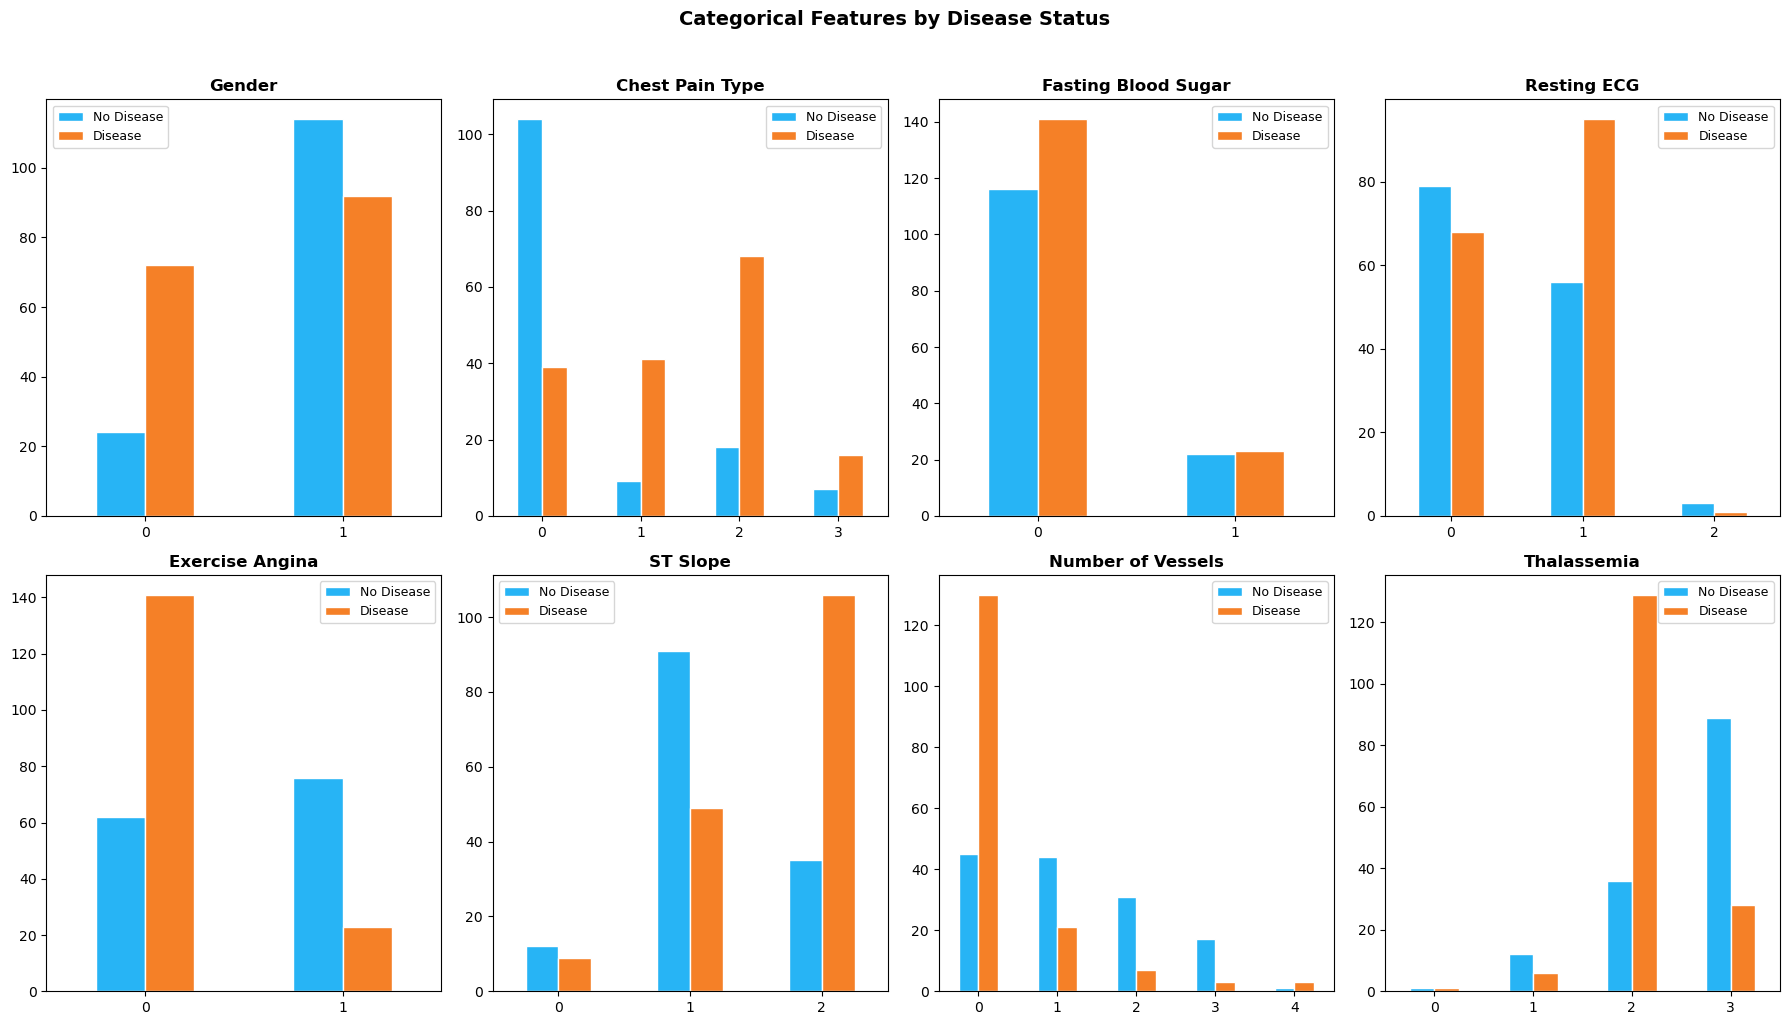

In [41]:
# Categorical features
cat_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
cat_labels = {
    'sex': 'Gender',
    'cp': 'Chest Pain Type',
    'fbs': 'Fasting Blood Sugar',
    'restecg': 'Resting ECG',
    'exang': 'Exercise Angina',
    'slope': 'ST Slope',
    'ca': 'Number of Vessels',
    'thal': 'Thalassemia'
}

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for idx, col in enumerate(cat_cols):
    ct = pd.crosstab(df[col], df['target'])
    ct.columns = ['No Disease', 'Disease']
    ct.plot(kind='bar', ax=axes[idx], color=['#27B4F5', '#F58027'],
            edgecolor='white', rot=0)
    axes[idx].set_title(cat_labels[col], fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('')
    axes[idx].legend(fontsize=9)

plt.suptitle('Categorical Features by Disease Status', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

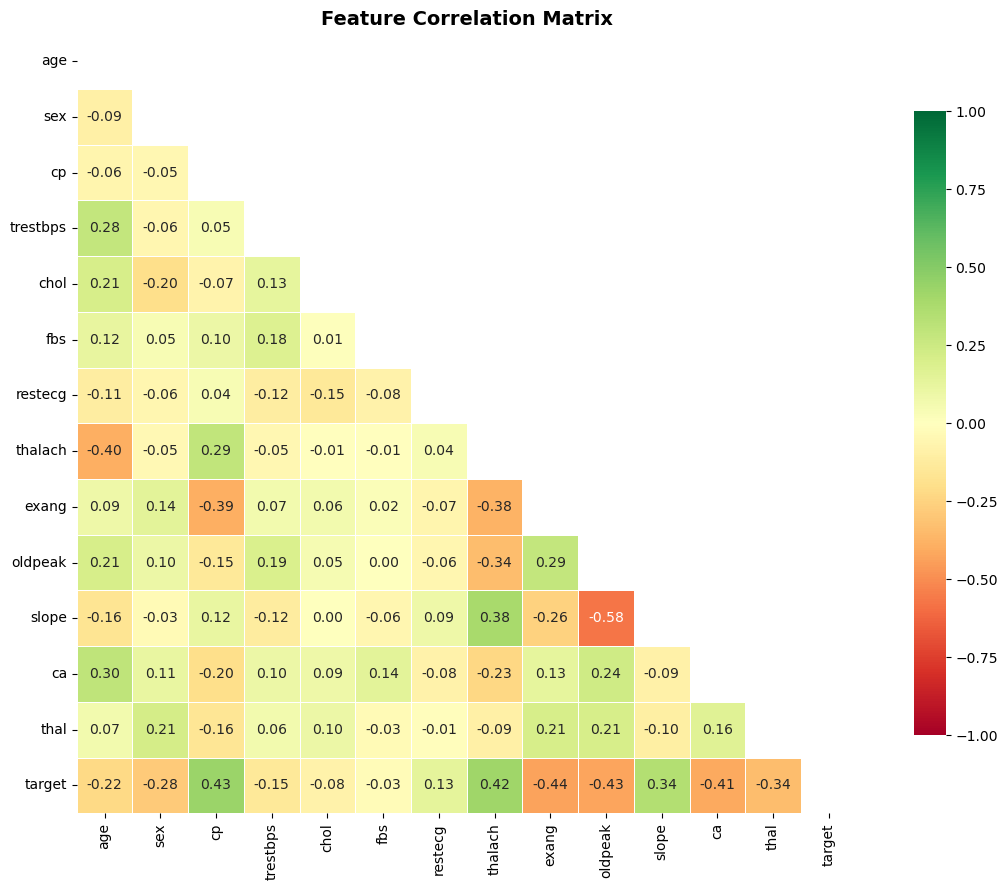


Feature correlation with target (sorted):
cp          0.432080
thalach     0.419955
slope       0.343940
restecg     0.134874
fbs        -0.026826
chol       -0.081437
trestbps   -0.146269
age        -0.221476
sex        -0.283609
thal       -0.343101
ca         -0.408992
oldpeak    -0.429146
exang      -0.435601


In [43]:
# Correlation matrix
plt.figure(figsize=(12, 9))
corr_matrix = df.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Show only lower triangle
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Highest correlation with target
print('\nFeature correlation with target (sorted):')
print(corr_matrix['target'].drop('target').sort_values(ascending=False).to_string())

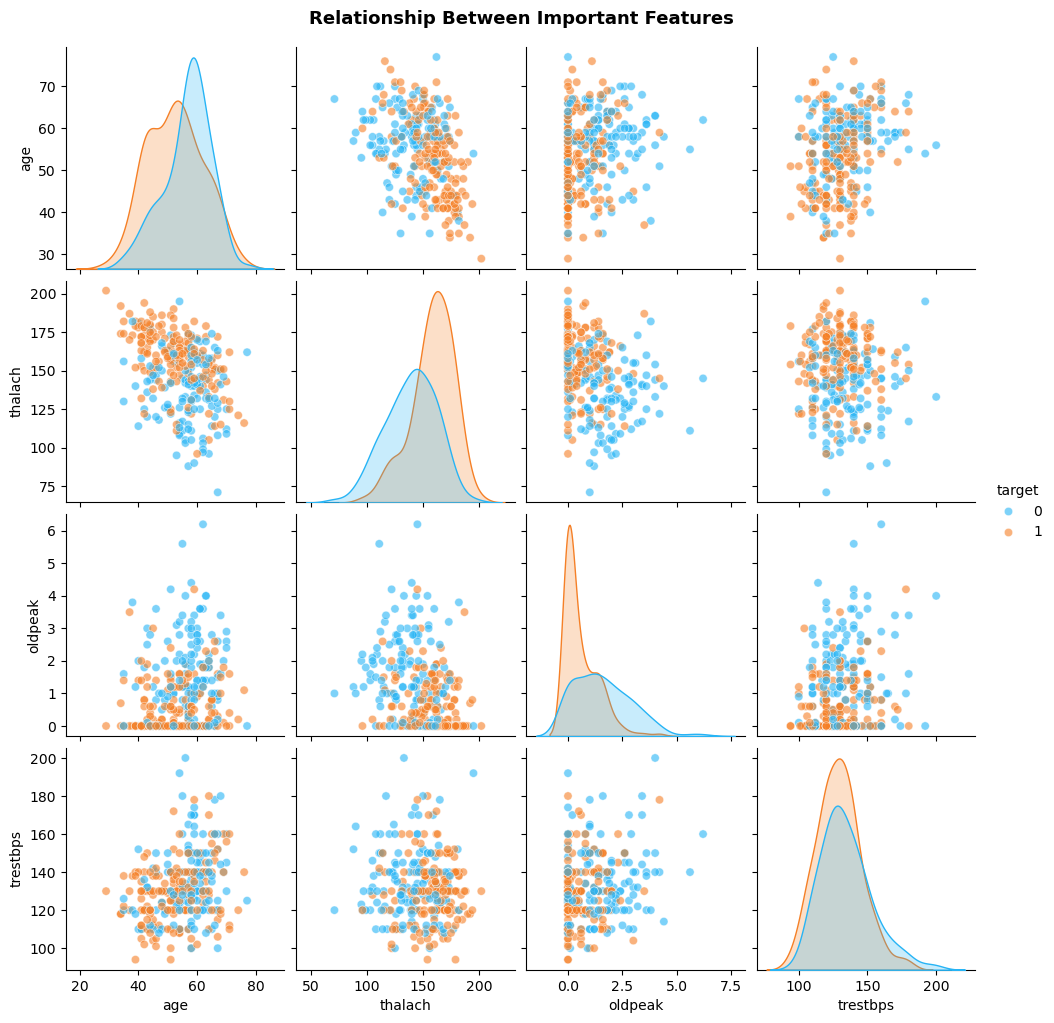

In [45]:
# Scatter plot of important features
important_cols = ['age', 'thalach', 'oldpeak', 'trestbps', 'target']
sns.pairplot(
    df[important_cols],
    hue='target',
    palette={0: '#27B4F5', 1: '#F58027'},
    diag_kind='kde',
    plot_kws={'alpha': 0.6}
)
plt.suptitle('Relationship Between Important Features', y=1.02, fontsize=13, fontweight='bold')
plt.show()

In [47]:
# Prepare data for modeling
X = df.drop('target', axis=1)
y = df['target']

print(f'Features (X): {X.shape}')
print(f'Target (y): {y.shape}')
print(f'\nFeatures list: {list(X.columns)}')

Features (X): (302, 13)
Target (y): (302,)

Features list: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


In [48]:
# Split data into Train/Test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Split results:')
print(f'Train: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'Test:  {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.0f}%)')

# Normalization (Scaling)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) 



Split results:
Train: 241 samples (80%)
Test:  61 samples (20%)


In [50]:
# Define models
models = {
    'Logistic Regression':    LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree':          DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest':          RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting':      GradientBoostingClassifier(n_estimators=100, random_state=42),
    'SVM':                    SVC(probability=True, random_state=42),
    'KNN':                    KNeighborsClassifier(n_neighbors=7)
}

# Train and evaluate
results = {}
print('Training models...\n')

for name, model in models.items():
    # Train
    model.fit(X_train_scaled, y_train)
    
    # Predict
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    
    # Cross-validation
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy')
    
    results[name] = {
        'Accuracy':  accuracy_score(y_test, y_pred),
        'ROC-AUC':   roc_auc_score(y_test, y_prob),
        'CV Mean':   cv_scores.mean(),
        'CV Std':    cv_scores.std(),
        'y_pred':    y_pred,
        'y_prob':    y_prob,
    }
    print(f'{name}: Accuracy={results[name]["Accuracy"]:.3f} | AUC={results[name]["ROC-AUC"]:.3f} | CV={results[name]["CV Mean"]:.3f}±{results[name]["CV Std"]:.3f}')

Training models...

Logistic Regression: Accuracy=0.803 | AUC=0.871 | CV=0.822±0.021
Decision Tree: Accuracy=0.770 | AUC=0.832 | CV=0.772±0.057
Random Forest: Accuracy=0.754 | AUC=0.859 | CV=0.817±0.034
Gradient Boosting: Accuracy=0.721 | AUC=0.826 | CV=0.784±0.033
SVM: Accuracy=0.770 | AUC=0.842 | CV=0.813±0.033
KNN: Accuracy=0.787 | AUC=0.860 | CV=0.826±0.017


In [51]:
# Comparison table
results_df = pd.DataFrame({
    name: {
        'Accuracy':  f"{v['Accuracy']:.3f}",
        'ROC-AUC':   f"{v['ROC-AUC']:.3f}",
        'CV Mean':   f"{v['CV Mean']:.3f}",
        'CV Std':    f"±{v['CV Std']:.3f}"
    }
    for name, v in results.items()
}).T

print('Model Comparison Table:')
results_df

Model Comparison Table:


,Accuracy,ROC-AUC,CV Mean,CV Std
Logistic Regression,0.803,0.871,0.822,±0.021
Decision Tree,0.770,0.832,0.772,±0.057
Random Forest,0.754,0.859,0.817,±0.034
Gradient Boosting,0.721,0.826,0.784,±0.033
SVM,0.770,0.842,0.813,±0.033
KNN,0.787,0.860,0.826,±0.017


/tmp/ipykernel_21560/2729526772.py:29: UserWarning: Glyph 127942 (\N{TROPHY}) missing from current font.
  plt.tight_layout()
/usr/lib/python3/dist-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 127942 (\N{TROPHY}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


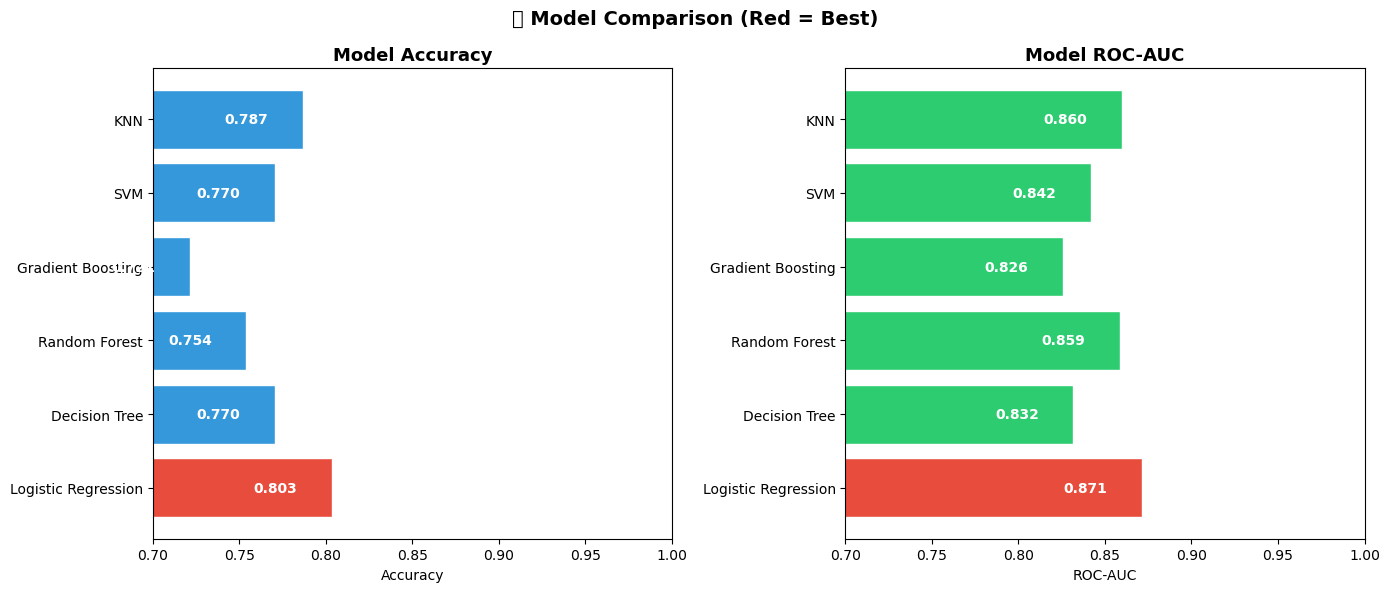

In [52]:
# Bar chart comparison of Accuracy and AUC
model_names = list(results.keys())
accuracies  = [results[m]['Accuracy'] for m in model_names]
aucs        = [results[m]['ROC-AUC']  for m in model_names]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Accuracy
colors = ['#e74c3c' if a == max(accuracies) else '#3498db' for a in accuracies]
bars = axes[0].barh(model_names, accuracies, color=colors, edgecolor='white')
for bar, acc in zip(bars, accuracies):
    axes[0].text(bar.get_width() - 0.02, bar.get_y() + bar.get_height()/2,
                 f'{acc:.3f}', va='center', ha='right', color='white', fontweight='bold')
axes[0].set_xlim(0.7, 1.0)
axes[0].set_title('Model Accuracy', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Accuracy')

# ROC-AUC
colors_auc = ['#e74c3c' if a == max(aucs) else '#2ecc71' for a in aucs]
bars2 = axes[1].barh(model_names, aucs, color=colors_auc, edgecolor='white')
for bar, auc in zip(bars2, aucs):
    axes[1].text(bar.get_width() - 0.02, bar.get_y() + bar.get_height()/2,
                 f'{auc:.3f}', va='center', ha='right', color='white', fontweight='bold')
axes[1].set_xlim(0.7, 1.0)
axes[1].set_title('Model ROC-AUC', fontsize=13, fontweight='bold')
axes[1].set_xlabel('ROC-AUC')

plt.suptitle('🏆 Model Comparison (Red = Best)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

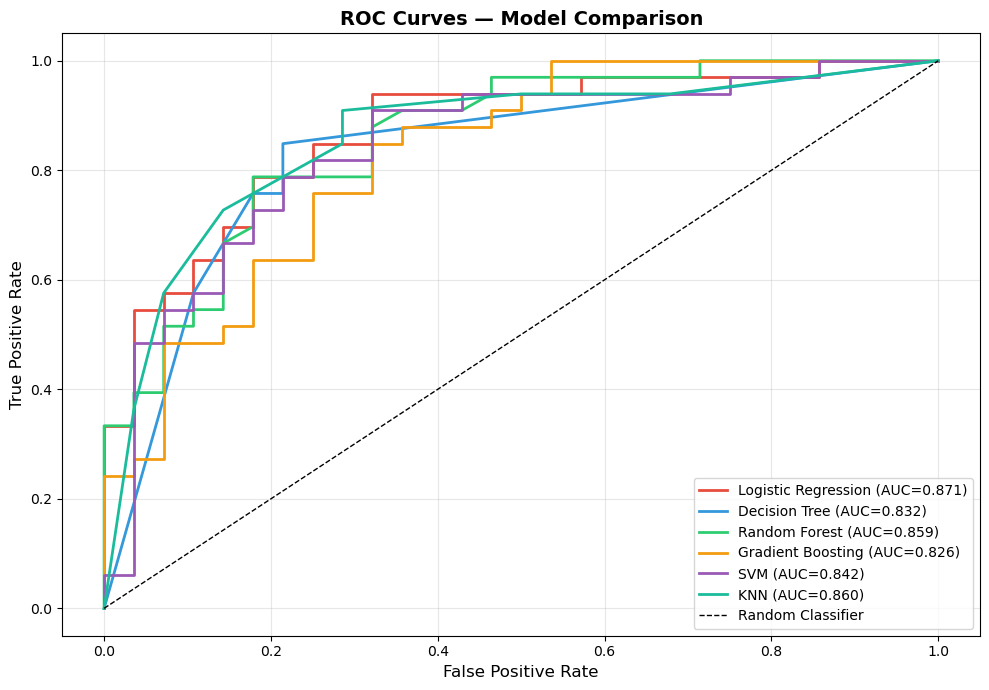

In [53]:
# ROC Curves for all models
plt.figure(figsize=(10, 7))
colors_roc = ['#e74c3c','#3498db','#2ecc71','#f39c12','#9b59b6','#1abc9c']

for (name, vals), color in zip(results.items(), colors_roc):
    fpr, tpr, _ = roc_curve(y_test, vals['y_prob'])
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f"{name} (AUC={vals['ROC-AUC']:.3f})")

plt.plot([0,1],[0,1], 'k--', lw=1, label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves — Model Comparison', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

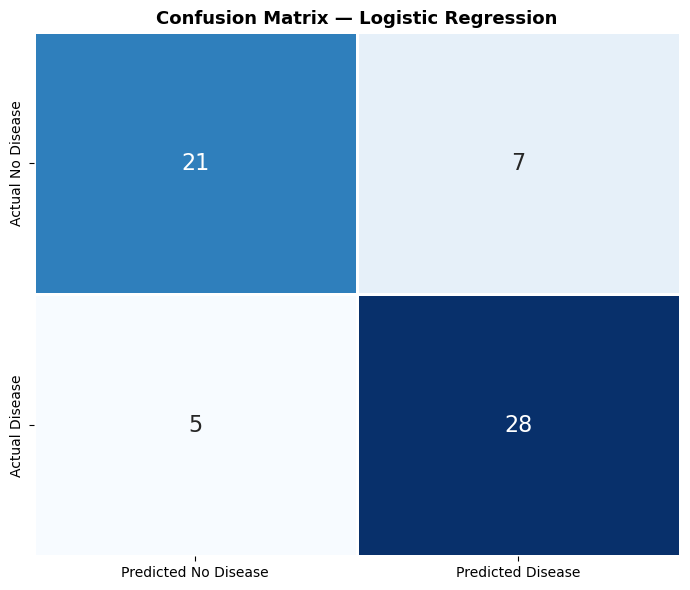


Complete Report for Logistic Regression:
              precision    recall  f1-score   support

  No Disease       0.81      0.75      0.78        28
     Disease       0.80      0.85      0.82        33

    accuracy                           0.80        61
   macro avg       0.80      0.80      0.80        61
weighted avg       0.80      0.80      0.80        61



In [56]:
# Confusion Matrix for best model
best_model_name = max(results, key=lambda x: results[x]['ROC-AUC'])
best_preds = results[best_model_name]['y_pred']

cm = confusion_matrix(y_test, best_preds)

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted No Disease', 'Predicted Disease'],
            yticklabels=['Actual No Disease', 'Actual Disease'],
            linewidths=2, cbar=False, annot_kws={'size': 16})
plt.title(f'Confusion Matrix — {best_model_name}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\nComplete Report for {best_model_name}:')
print(classification_report(y_test, best_preds, target_names=['No Disease', 'Disease']))

/tmp/ipykernel_21560/3742488653.py:13: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from current font.
  plt.tight_layout()
/usr/lib/python3/dist-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


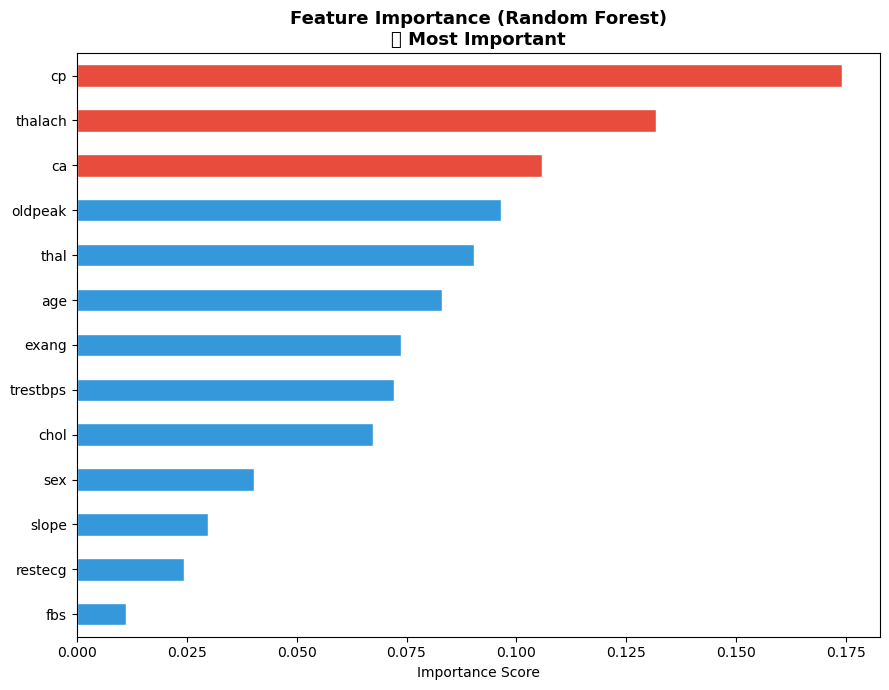

🏆 Top 5 Most Important Features:
cp         0.173969
thalach    0.131634
ca         0.105700
oldpeak    0.096577
thal       0.090418


In [57]:
# Feature importance (from Random Forest)
rf_model = models['Random Forest']
feature_imp = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=True)

plt.figure(figsize=(9, 7))
colors_fi = ['#e74c3c' if x > feature_imp.quantile(0.75) else '#3498db' for x in feature_imp]
feature_imp.plot(kind='barh', color=colors_fi, edgecolor='white')
plt.title('Feature Importance (Random Forest)\n🔴 Most Important', fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print('🏆 Top 5 Most Important Features:')
print(feature_imp.tail(5)[::-1].to_string())